In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(1338, 7)

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df = df.drop_duplicates()

df.shape

(1337, 7)

In [11]:
numeric_cols = ["age","bmi","children","charges"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col]>=lower) & (df[col]<=upper)]

df.shape

(1190, 7)

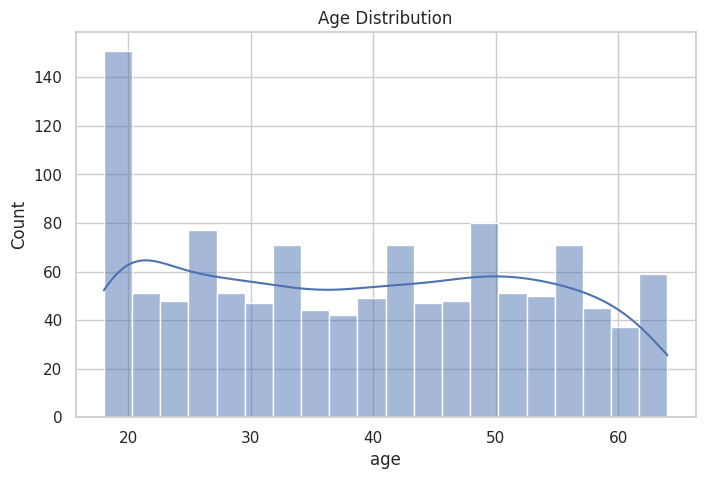

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

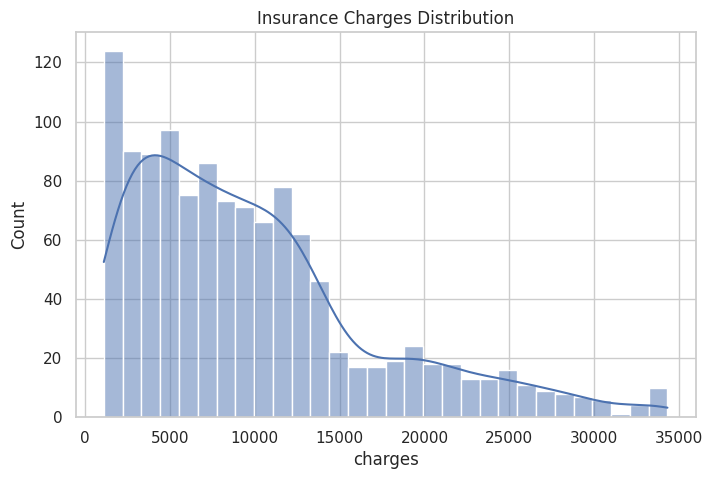

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Insurance Charges Distribution")

plt.show()

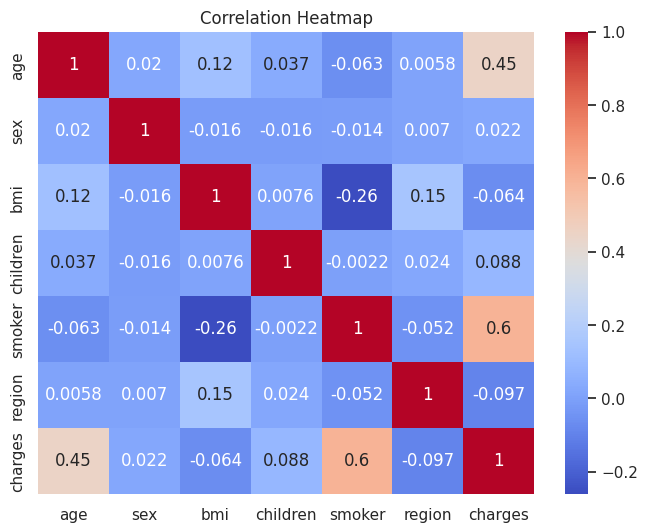

In [14]:
df_encoded = df.copy()

df_encoded["sex"] = df_encoded["sex"].map({"male":0,"female":1})

df_encoded["smoker"] = df_encoded["smoker"].map({"no":0,"yes":1})

df_encoded["region"] = df_encoded["region"].astype("category").cat.codes

plt.figure(figsize=(8,6))

sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

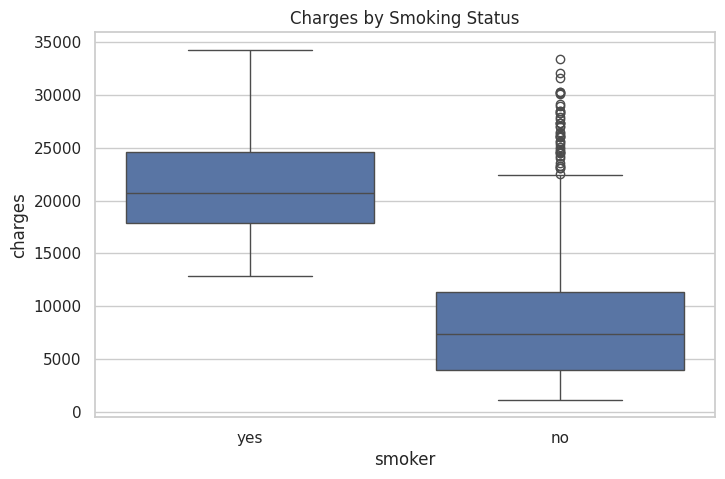

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Charges by Smoking Status")

plt.show()

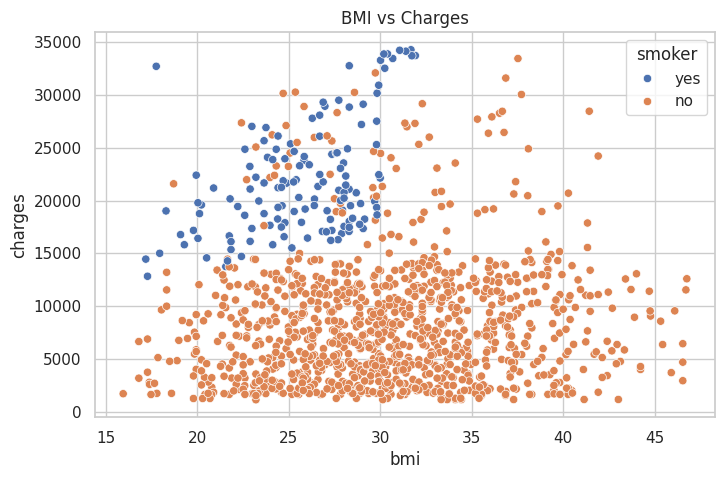

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df)

plt.title("BMI vs Charges")

plt.show()

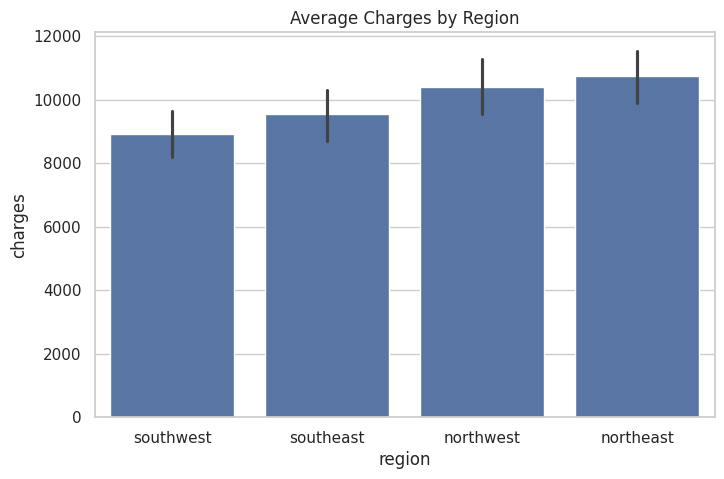

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(x="region", y="charges", data=df)

plt.title("Average Charges by Region")

plt.show()

In [19]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0,18.5,25,30,100],
    labels=["Underweight","Normal","Overweight","Obese"]
)

In [20]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,100],
    labels=["Young","Adult","Middle Age","Senior"]
)

In [21]:
df["family_size"] = df["children"] + 1

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young,1
1,18,male,33.770,1,no,southeast,1725.55230,Obese,NaN,2
2,28,male,33.000,3,no,southeast,4449.46200,Obese,Young,4
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Adult,1
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Adult,1
